In [83]:
import sys, pdb, string,os, glob
import numpy as np
from numpy import log10 as log, log as ln
import h5py
from scipy import interpolate
import astropy, astropy.cosmology
from astropy import units as un, constants as cons
from astropy.cosmology import Planck15 as cosmo
import pylab as pl, matplotlib
from matplotlib import cm
homedir = os.environ["HOME"]
projectdir = homedir+'/Dropbox/github_repositories/cgm_models/TurbDominated/'


In [2]:
olddir = homedir+'/Dropbox/other_repositories/rpc_hydro/pysrc/'
#olddir = homedir+'/Dropbox/jonathanmain/CGM/multiDensityModelling/'
sys.path.append(olddir)
import Cloudy
sys.path.append('../../gizmo_analysis/pysrc/')
import my_utils as u
from rc import *
matplotlib.rcParams['mathtext.fontset'] = 'cm'
matplotlib.rc('font', family='serif', size=10)
matplotlib.rcParams['xtick.direction'] = 'in'
matplotlib.rcParams['ytick.direction'] = 'in'
matplotlib.rcParams['xtick.top'] = True
matplotlib.rcParams['ytick.right'] = True

# parameters

In [3]:
#model_name,alpha,mach,Z02,Zindex,f_gas = 'fiducial',2.3,5.6,0.3,-0.6,0.6  #m12i
model_name,alpha,mach,Z02,Zindex,f_gas = 'm12b',    2.3,5.0,0.4,-0.8,0.5  
#model_name,alpha,mach,Z02,Zindex,f_gas = 'm12f',    2.2,4.7,0.4,-0.5,0.5  
#model_name,alpha,mach,Z02,Zindex,f_gas = 'm12c',    1.9,6.0,0.2,-0.7,0.6  
#model_name,alpha,mach,Z02,Zindex,f_gas = 'm12w',    2.7,5.5,0.2,-0.8,0.6  
Z2Zsun = lambda r2Rvir: Z02 * (r2Rvir/0.2)**Zindex
Rvir = 140*un.kpc
z = 1.5
b = 1
X = 0.7

In [4]:
elements = 'Mg','Mg','C','Al','Al','Fe','C','C','C','Si','Si','Si','O','H','S','P'
solar_abundances=(10**-4.4,10**-4.4,10**-3.57,10**-5.55,10**-5.55,10**-4.5,10**-3.57,10**-3.57,10**-3.57,
                  10**-4.49,10**-4.49,10**-4.49,10**-3.31,1.,10**-4.88,10**-6.59)
ionLevels=1,0,3,1,2,1,0,1,2,1,2,3,0,0,0,0

# lognormal parameters

In [5]:
def mean_log_n_volume_weighted(r2Rvir, z,f_gas=f_gas, alpha=alpha,X=X):
    x_BN = cosmo.Om(z) - 1
    Delta_c = 18 * np.pi ** 2 + 82 * x_BN - 39 * x_BN ** 2
    rho_Rvir = (1-alpha/3)*f_gas*Delta_c*cosmo.Ob0/cosmo.Om0*cosmo.critical_density(z)
    rho = rho_Rvir * r2Rvir**-alpha
    nH = X*rho/cons.m_p
    return log(nH.to('cm**-3').value)

In [6]:
def sigma_s(mach=mach,b=b):
    return ln(1+b**2*mach**2)**0.5

In [7]:
def PDF_volume_weighted(log_n,mean_log_n_volume_weighted,sigma_s): #per bin size of 1 in natural logarithm
    s = (log_n - mean_log_n_volume_weighted)*ln(10)
    mu_s = -sigma_s**2/2.
    return (2*np.pi)**-0.5/sigma_s * np.e**(-(s-mu_s)**2/(2*sigma_s**2))

In [8]:
all_log_ns = np.linspace(-7,3,101)
dlog_ns = 0.1
dln_ns = dlog_ns * ln(10)
all_r2Rvirs = 10.**np.linspace(-1.3,0.5,18001)
log_ns_v, r2Rvirs_v = np.meshgrid(all_log_ns, all_r2Rvirs)
r2Rvir_midbins = (r2Rvirs_v[1:,:]+r2Rvirs_v[:-1,:])/2.
log_ns_v_midbins = (log_ns_v[1:,:]+log_ns_v[:-1,:])/2.
nHs = 10.**log_ns_v_midbins*un.cm**-3

In [9]:
weights_lognormal_volume_weighted = PDF_volume_weighted(log_ns_v_midbins,mean_log_n_volume_weighted(r2Rvir_midbins,z),sigma_s(mach))

# optically thin calculation

In [10]:
def ionFractions(log_ns, log_Ts, element='O',ionizationLevel=5,z=0,fn='/Users/jonathanstern/.trident/hm2012_hr.h5'):
    F = h5py.File(fn,'r')
    logT        = np.array(F[element].attrs['Temperature'])
    lognH       = np.array(F[element].attrs['Parameter1'])
    z_hm2012    = np.array(F[element].attrs['Parameter2'])   
    ind_z        = u.searchsortedclosest(z_hm2012,z)                
    log_f_tab   = np.array(F[element])[ionizationLevel,:,ind_z,:]
    func = interpolate.RectBivariateSpline(lognH,logT, log_f_tab)
    res = func.ev(log_ns,log_Ts)
    F.close()
    return 10.**res

In [11]:
#import xarray as xr
#data = xr.open_dataarray(projectdir+'cloudy_equilibrium_temperature.nc')
#data.nh,data.sel(redshift=0.75,method='nearest')
def log_T(log_n,z=z):
    #return log(2.6e4*10**(-0.23*(log_n-(-4.5+3*log(1+z)))))
    log_Ts = 6 - 2/3.*(log_n+4) #fig. 2 in Kakoly+25
    log_Ts[log_Ts<4.1] = 4.1
    return log_Ts

/Library/Frameworks/Python.framework/Versions/2.7/lib/python2.7/site-packages/ipykernel_launcher.py:7: RuntimeWarning: invalid value encountered in sqrt
  import sys


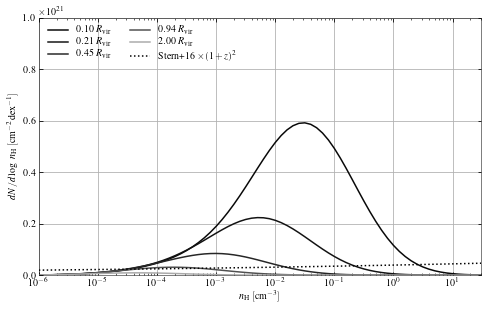

In [12]:
Rperp2Rvirs_thin = 10.**np.arange(-1,0.31,0.325)
Nions = np.zeros((len(elements),len(Rperp2Rvirs_thin)))
for iIon in range(len(elements)):
    f_ions = ionFractions(log_ns_v_midbins,log_T(log_ns_v_midbins),elements[iIon],ionLevels[iIon],z=z)
    nIons = nHs*solar_abundances[iIon]*Z2Zsun(r2Rvir_midbins)*f_ions
    for iRperp, Rperp2Rvir in enumerate(Rperp2Rvirs_thin):
        weights_los       = 2 * ((r2Rvirs_v[1:,:]**2 - Rperp2Rvir**2)**0.5 - (r2Rvirs_v[:-1,:]**2 - Rperp2Rvir**2)**0.5) * Rvir
        weights_los[np.isnan(weights_los)] = 0
        if iIon==0:
            pl.plot(nHs[0,:],(nHs*weights_lognormal_volume_weighted*weights_los).sum(axis=0).to('cm**-2').value * ln(10.),
                    label=r'$%.2f\ R_{\rm vir}$'%Rperp2Rvir,c=cm.gray(Rperp2Rvir/3))
        Nions[iIon,iRperp] = ((nIons*weights_lognormal_volume_weighted*weights_los).sum()).to('cm**-2').value
pl.ylabel(r'$d N/d\log\ n_{\rm H}\ [{\rm cm}^{-2}\,{\rm dex}^{-1}]$')
pl.xlabel(r'$n_{\rm H}\ [{\rm cm}^{-3}]$')
pl.semilogx()
pl.plot(nHs[0,:],10**18.54*(nHs[0,:].value/7e-6)**0.05 * 2.5**2,ls=':',c='k',label=r'Stern+16 $\times(1+z)^2$')
pl.legend(ncol=2,loc='upper left',frameon=False)
pl.ylim(0,1.e21)
pl.xlim(1e-6,30)
pl.grid()


/Library/Frameworks/Python.framework/Versions/2.7/lib/python2.7/site-packages/ipykernel_launcher.py:2: RuntimeWarning: invalid value encountered in sqrt
  


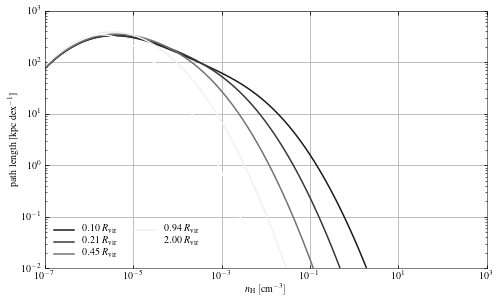

In [13]:
for iRperp, Rperp2Rvir in enumerate(Rperp2Rvirs_thin):
    weights_los       = 2 * ((r2Rvirs_v[1:,:]**2 - Rperp2Rvir**2)**0.5 - (r2Rvirs_v[:-1,:]**2 - Rperp2Rvir**2)**0.5) * Rvir
    weights_los[np.isnan(weights_los)] = 0
    pl.plot(nHs[0,:],(weights_lognormal_volume_weighted*weights_los).sum(axis=0).to('kpc').value * ln(10.),
        label=r'$%.2f\ R_{\rm vir}$'%Rperp2Rvir,c=cm.gray(Rperp2Rvir))
pl.ylabel(r'path length [kpc dex$^{-1}$]')
pl.xlabel(r'$n_{\rm H}\ [{\rm cm}^{-3}]$')
pl.loglog()
pl.legend(ncol=2,loc='lower left',frameon=False)
pl.ylim(1e-2,1e3)
pl.xlim(1e-7,1e3)
pl.grid()

(10000000000.0, 1e+20)

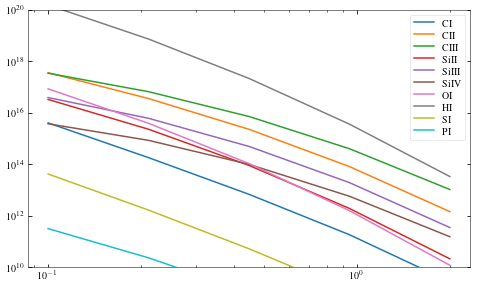

In [14]:
for iIon in range(len(elements)):
    if iIon<6: continue
    pl.plot(Rperp2Rvirs_thin,Nions[iIon],label='%s%s'%(elements[iIon],u.roman[ionLevels[iIon]+1]))
pl.loglog()
pl.legend()
pl.ylim(1e10,1e20)

# optically thick calculation

In [15]:
Rperp2Rvirs = 10.**np.linspace(-1.,0.3,41)

In [16]:
dir_name = r'density_law_files/%s'%model_name
output_dir_name = r'output/%s'%model_name
try: 
    os.mkdir(dir_name)
    os.mkdir(output_dir_name)
    os.mkdir(output_dir_name+'/cloudy_slab_structure')
except OSError as e:
    print(e); print('Continuing...'); pass

[Errno 17] File exists: 'density_law_files/m12b'
Continuing...


/Library/Frameworks/Python.framework/Versions/2.7/lib/python2.7/site-packages/ipykernel_launcher.py:3: RuntimeWarning: invalid value encountered in sqrt
  This is separate from the ipykernel package so we can avoid doing imports until


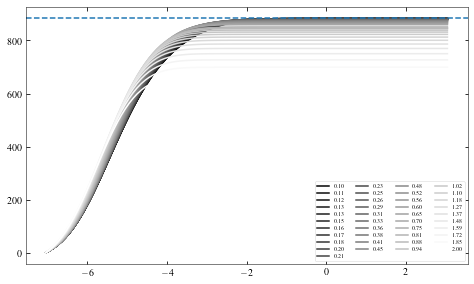

In [17]:
fn_template = dir_name + r'/density_law_Rperp2Rvir%.2f_z%.2f_mach%d_Z%.2f_Rvir%d.npz'
for iRperp, Rperp2Rvir in enumerate(Rperp2Rvirs):
    weights_los       = 2 * ((r2Rvirs_v[1:,:]**2 - Rperp2Rvir**2)**0.5 - (r2Rvirs_v[:-1,:]**2 - Rperp2Rvir**2)**0.5) * Rvir
    weights_los[np.isnan(weights_los)] = 0
    ddepths = (weights_lognormal_volume_weighted*weights_los).sum(axis=0).to('cm').value * dln_ns
    depths = np.concatenate([np.array([1e-35]),np.cumsum(ddepths)])
    fixed_log_ns = np.concatenate([np.array([all_log_ns[0]-dlog_ns/2]),all_log_ns+dlog_ns/2])
    fn = fn_template%(Rperp2Rvir,z,mach,Z2Zsun(Rperp2Rvir),Rvir.value)
    np.savez(fn,log_n=fixed_log_ns,log_r=log(depths),log_T=np.zeros(len(all_log_ns)))
    pl.plot(fixed_log_ns, depths/3e21,label='%.2f'%Rperp2Rvir,c=cm.gray(iRperp/40.))
pl.legend(fontsize=6,ncol=4)
pl.axhline(2*all_r2Rvirs[-1]*Rvir.value,ls='--')

/Library/Frameworks/Python.framework/Versions/2.7/lib/python2.7/site-packages/ipykernel_launcher.py:2: RuntimeWarning: invalid value encountered in sqrt
  


Text(0,0.5,'$\\log\\ n_{\\rm H}\\ [{\\rm cm}^{-3}]$')

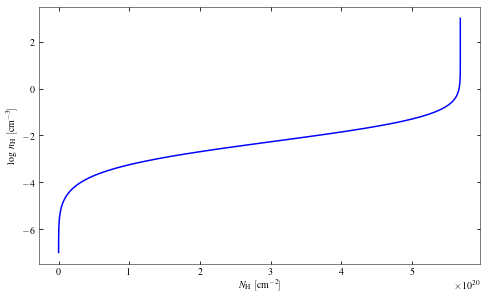

In [18]:
Rperp2Rvir=Rperp2Rvirs[9] #0.2
weights_los       = 2 * ((r2Rvirs_v[1:,:]**2 - Rperp2Rvir**2)**0.5 - (r2Rvirs_v[:-1,:]**2 - Rperp2Rvir**2)**0.5) * Rvir
weights_los[np.isnan(weights_los)] = 0
dNs = (nHs*weights_lognormal_volume_weighted*weights_los).sum(axis=0).to('cm**-2').value * dln_ns
ddepths = (weights_lognormal_volume_weighted*weights_los).sum(axis=0).to('cm').value * dln_ns
depths = np.concatenate([np.array([1e-35]),np.cumsum(ddepths)])
fixed_log_ns = np.concatenate([np.array([all_log_ns[0]-dlog_ns/2]),all_log_ns+dlog_ns/2])
pl.plot(((depths[1:]-depths[:-1])*10.**all_log_ns).cumsum(),all_log_ns,label='%.2f'%Rperp2Rvir,c='b')
pl.xlabel(r'$N_{\rm H}\ [{\rm cm}^{-2}]$')
pl.ylabel(r'$\log\ n_{\rm H}\ [{\rm cm}^{-3}]$')

In [19]:
fn_template = dir_name+r'/density_law_Rperp2Rvir*_z%.2f_mach%d_Z*_Rvir%d.npz'%(z,mach,Rvir.value)
profile_fns = glob.glob(fn_template)
strfunc = lambda fn: fn.split('_')[4]
Zfunc = lambda fn: float(fn.split('_')[7][-4:])

In [20]:
reload(Cloudy)
reload(u)
Cloudy.Model.basedir = projectdir+'CloudyOutput/'
Cloudy.dataDir = projectdir
Cloudy.Model.cloudyexe = homedir+'/programs/Cloudy/c23.01/source/cloudy.exe'
#hmsp = Cloudy.loadHMspectra()[3]
#hmsp.plot()

In [79]:
#Metallicity of innermost radius used for all cloud!!. 
# Can in principle be changed using command "Element <name> table depth" for all elements
ConstDensityGrid = Cloudy.Grid('constdensitygrid', colDenss=np.arange(15,23,0.1),neutralColumn=True,stopT=100,
                               ns=np.arange(-7,3.1,.5),
                               turbulences=[100.], #effect of turbulence is negligible
                            Zs=[0.3],
                            HMzs=[z],dusties=[False], emittedRadiationPressure=False,ps=[False],
                         emissionLines=Cloudy.emissionLines[:1],
                         savelevel=1,strfunc = strfunc,forCompatibility='HNZn',nDigitsDic={'Z':2})  #H is redshift

In [80]:
ConstDensityGrid.writeinputfiles()

In [81]:
len(ConstDensityGrid)

1680

In [82]:
ConstDensityGrid.run(12)

Grid.run()
module name: my_utils
parent process: 27755
process id: 30098
running (18:58:03): constdensitygrid_n-7.0_Z0.30_N15.0_H1.5 process id: 30501
running (18:58:03): constdensitygrid_n-7.0_Z0.30_N15.1_H1.5 process id: 30502
running (18:58:03): constdensitygrid_n-7.0_Z0.30_N15.3_H1.5 process id: 30504
running (18:58:03): constdensitygrid_n-7.0_Z0.30_N15.9_H1.5 process id: 30510
running (18:58:03): constdensitygrid_n-7.0_Z0.30_N15.2_H1.5 process id: 30503
running (18:58:03): constdensitygrid_n-7.0_Z0.30_N15.4_H1.5 process id: 30505
# of models to run: 1680
running (18:58:03): constdensitygrid_n-7.0_Z0.30_N15.5_H1.5 process id: 30506
running (18:58:03): constdensitygrid_n-7.0_Z0.30_N15.6_H1.5 process id: 30507
running (18:58:03): constdensitygrid_n-7.0_Z0.30_N15.7_H1.5 process id: 30508
running (18:58:03): constdensitygrid_n-7.0_Z0.30_N15.8_H1.5 process id: 30509
running (18:58:03): constdensitygrid_n-7.0_Z0.30_N16.0_H1.5 process id: 30511
running (18:58:03): constdensitygrid_n-7.0_Z

ending (19:00:31): constdensitygrid_n-7.0_Z0.30_N15.0_H1.5 process id: 30501
ending (19:00:31): constdensitygrid_n-7.0_Z0.30_N15.1_H1.5 process id: 30502
running (19:00:31): constdensitygrid_n-7.0_Z0.30_N16.2_H1.5 process id: 30572
running (19:00:31): constdensitygrid_n-7.0_Z0.30_N16.3_H1.5 process id: 30573
ending (19:00:42): constdensitygrid_n-7.0_Z0.30_N15.2_H1.5 process id: 30503
running (19:00:42): constdensitygrid_n-7.0_Z0.30_N16.4_H1.5 process id: 30578
ending (19:00:48): constdensitygrid_n-7.0_Z0.30_N15.3_H1.5 process id: 30504
running (19:00:48): constdensitygrid_n-7.0_Z0.30_N16.5_H1.5 process id: 30580
ending (19:00:59): constdensitygrid_n-7.0_Z0.30_N15.4_H1.5 process id: 30505
running (19:00:59): constdensitygrid_n-7.0_Z0.30_N16.6_H1.5 process id: 30582
ending (19:01:05): constdensitygrid_n-7.0_Z0.30_N15.6_H1.5 process id: 30507
running (19:01:05): constdensitygrid_n-7.0_Z0.30_N16.7_H1.5 process id: 30587
ending (19:01:05): constdensitygrid_n-7.0_Z0.30_N15.5_H1.5 process id:

In [165]:
#u.mifkad(ConstDensityGrid('CloudyOk').values())
bads = sorted([k for k,m in ConstDensityGrid.items() if not m.CloudyOk()],key=lambda k: k[2])

In [87]:
ConstDensityGrid.loadAll()

progress:  99% 931 seconds passed


In [88]:
ConstDensityGrid.colDenss

array([15. , 15.1, 15.2, 15.3, 15.4, 15.5, 15.6, 15.7, 15.8, 15.9, 16. ,
       16.1, 16.2, 16.3, 16.4, 16.5, 16.6, 16.7, 16.8, 16.9, 17. , 17.1,
       17.2, 17.3, 17.4, 17.5, 17.6, 17.7, 17.8, 17.9, 18. , 18.1, 18.2,
       18.3, 18.4, 18.5, 18.6, 18.7, 18.8, 18.9, 19. , 19.1, 19.2, 19.3,
       19.4, 19.5, 19.6, 19.7, 19.8, 19.9, 20. , 20.1, 20.2, 20.3, 20.4,
       20.5, 20.6, 20.7, 20.8, 20.9, 21. , 21.1, 21.2, 21.3, 21.4, 21.5,
       21.6, 21.7, 21.8, 21.9, 22. , 22.1, 22.2, 22.3, 22.4, 22.5, 22.6,
       22.7, 22.8, 22.9])

In [166]:
ionstrs = 'HI','CI','CII','CIII','CIV','OI','SiII','SiIII','AlII','AlIII','FeII','MgI','MgII'
ions = map(Cloudy.Ion,ionstrs)
Teqs  = np.zeros((ConstDensityGrid.colDenss.shape[0],ConstDensityGrid.ns.shape[0]))
NHIs  = np.zeros((ConstDensityGrid.colDenss.shape[0],ConstDensityGrid.ns.shape[0]))
NHs   = np.zeros((ConstDensityGrid.colDenss.shape[0],ConstDensityGrid.ns.shape[0]))
fions = np.zeros((ConstDensityGrid.colDenss.shape[0],ConstDensityGrid.ns.shape[0],len(ions)))
goods = [(k,m) for k,m in ConstDensityGrid.items() if m.CloudyOk()]
for iN,NHI in enumerate(u.Progress(ConstDensityGrid.colDenss[::])):
    for inH,nH in enumerate(ConstDensityGrid.ns):
        realgoods = [(k,m) for k,m in goods if k[0]==nH and k[2]==NHI]
        if len(realgoods)!=1:
            print(len(realgoods))
            continue
        k,m = realgoods[0]
        Teqs[iN,inH] = m.Ts[-1] 
        NHIs[iN,inH] = m.Nion('HI')[-1]
        NHs[iN,inH] = m.Nion('HI')[-1]+m.Nion('HII')[-1]
        fions[iN,inH,:] = np.array([m.elementStates[str(ion.el)][ion.ionLevel][-1] for ion in ions])

IndentationError: expected an indented block (<ipython-input-166-6d0b64924ed2>, line 18)

In [177]:
for iN,NHI in enumerate(ConstDensityGrid.colDenss[::]):
    for inH,nH in enumerate(ConstDensityGrid.ns):
        realbads = [k for k in bads if k[0]==nH and k[2]==NHI]
        if len(realbads)!=1:
            continue
        k,m = realbads[0],ConstDensityGrid[realbads[0]]
        print(k)
        Teqs[iN,inH] = 10.**np.mean([log(Teqs[iN,inH-1]),log(Teqs[iN,inH+1])])
        NHs[iN,inH] = 10.**np.mean([log(NHs[iN,inH-1]),log(NHs[iN,inH+1])])
        NHIs[iN,inH] = 10.**np.mean([log(NHIs[iN,inH-1]),log(NHIs[iN,inH+1])])
        fions[iN,inH,:] = np.mean(np.array([log(fions[iN,inH-1,:]),log(fions[iN,inH+1,:])]),axis=0)

(1.5, 0.3, 17.499999999999993, 1.5)
(1.5, 0.3, 17.89999999999999, 1.5)
(1.5, 0.3, 17.99999999999999, 1.5)
(1.5, 0.3, 18.19999999999999, 1.5)
(1.5, 0.3, 18.29999999999999, 1.5)
(1.5, 0.3, 18.399999999999988, 1.5)
(1.5, 0.3, 18.499999999999986, 1.5)
(1.5, 0.3, 18.599999999999987, 1.5)
(1.5, 0.3, 18.69999999999999, 1.5)
(1.5, 0.3, 18.799999999999986, 1.5)
(1.5, 0.3, 18.899999999999984, 1.5)
(1.5, 0.3, 18.999999999999986, 1.5)
(1.5, 0.3, 19.099999999999987, 1.5)
(1.5, 0.3, 19.299999999999983, 1.5)
(1.5, 0.3, 19.399999999999984, 1.5)
(1.5, 0.3, 19.499999999999986, 1.5)
(1.5, 0.3, 19.599999999999984, 1.5)
(1.5, 0.3, 19.69999999999998, 1.5)
(1.5, 0.3, 19.899999999999984, 1.5)
(1.5, 0.3, 19.999999999999982, 1.5)
(1.5, 0.3, 20.09999999999998, 1.5)
(1.5, 0.3, 20.19999999999998, 1.5)
(1.5, 0.3, 20.299999999999983, 1.5)
(1.5, 0.3, 20.39999999999998, 1.5)
(1.5, 0.3, 20.49999999999998, 1.5)
(1.5, 0.3, 20.79999999999998, 1.5)
(1.5, 0.3, 21.09999999999998, 1.5)
(1.5, 0.3, 21.199999999999978, 1.5)
(1.5

/Library/Frameworks/Python.framework/Versions/2.7/lib/python2.7/site-packages/ipykernel_launcher.py:11: RuntimeWarning: invalid value encountered in log10
  # This is added back by InteractiveShellApp.init_path()
/Library/Frameworks/Python.framework/Versions/2.7/lib/python2.7/site-packages/ipykernel_launcher.py:11: RuntimeWarning: divide by zero encountered in log10
  # This is added back by InteractiveShellApp.init_path()


Text(0,0.5,'$N_{\\rm HI}\\ [{\\rm cm}^{-2}]$')

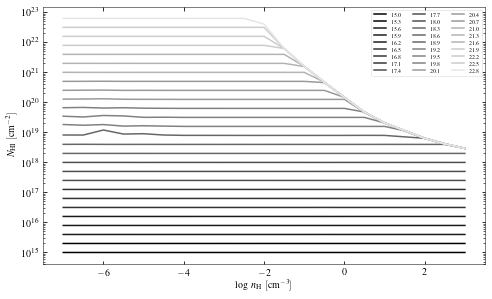

In [184]:
[pl.plot(ConstDensityGrid.ns,NHIs[iN*3,:],'-',c='%.1f'%(iN/30.),label='%.1f'%N) 
 for iN,N in enumerate(ConstDensityGrid.colDenss[::3])]
pl.legend(ncol=3,fontsize=6)
pl.semilogy(); pl.xlabel(r'$\log\ n_{\rm H}\ [{\rm cm}^{-3}]$'); pl.ylabel(r'$N_{\rm HI}\ [{\rm cm}^{-2}]$')

Text(0,0.5,'$N_{\\rm H}\\ [{\\rm cm}^{-2}]$')

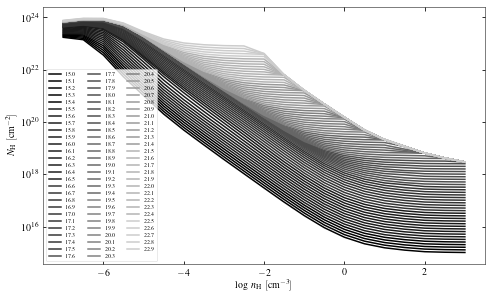

In [185]:
[pl.plot(ConstDensityGrid.ns,NHs[iN,:],'-',c='%.1f'%(iN/100.),label='%.1f'%N) 
 for iN,N in enumerate(ConstDensityGrid.colDenss)]
pl.legend(ncol=3,fontsize=6)
pl.semilogy(); pl.xlabel(r'$\log\ n_{\rm H}\ [{\rm cm}^{-3}]$'); pl.ylabel(r'$N_{\rm H}\ [{\rm cm}^{-2}]$')

Text(0,0.5,'$T_{\\rm eq}\\ [{\\rm K}]$')

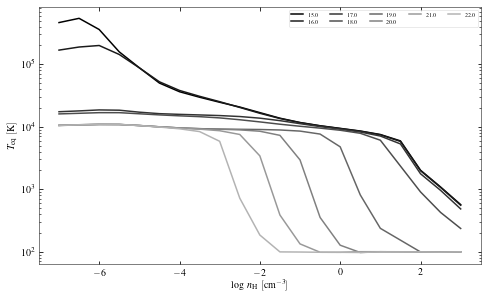

In [208]:
[pl.plot(ConstDensityGrid.ns,Teqs[iN*10,:],'-',c='%.1f'%(iN/10.),label='%.1f'%N) 
 for iN,N in enumerate(ConstDensityGrid.colDenss[::10])]
pl.legend(ncol=5,fontsize=6)
pl.semilogy(); pl.xlabel(r'$\log\ n_{\rm H}\ [{\rm cm}^{-3}]$'); pl.ylabel(r'$T_{\rm eq}\ [{\rm K}]$')

Text(0,0.5,'$f_{\\rm AlIII}$')

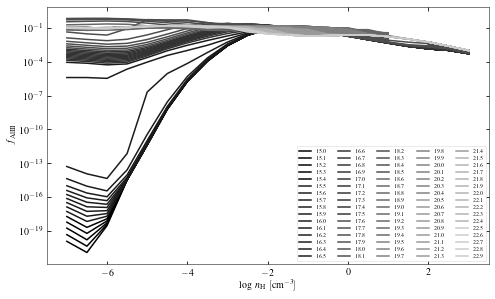

In [195]:
[pl.plot(ConstDensityGrid.ns,10.**fions[iN,:,9],'-',c='%.1f'%(iN/100.),label='%.1f'%N) 
 for iN,N in enumerate(ConstDensityGrid.colDenss[::])]
pl.legend(ncol=5,fontsize=6)
pl.semilogy(); pl.xlabel(r'$\log\ n_{\rm H}\ [{\rm cm}^{-3}]$'); pl.ylabel(r'$f_{\rm %s}$'%(ions[9]))

In [198]:
pl.savez('Teqs_and_fions.npz', nHs = ConstDensityGrid.ns, NHs=NHs, NHIs=NHIs, Teqs=Teqs,fions=fions,ions=np.array(ionstrs))

In [199]:
f = pl.load('Teqs_and_fions.npz')

In [ ]:
#Metallicity of innermost radius used for all cloud!!. 
# Can in principle be changed using command "Element <name> table depth" for all elements
LogNormalGrid = Cloudy.Grid('lognormalgrid-%s'%model_name, stopT=10,turbulences=[100.], #effect of turbulence is negligible
                            profile_fns=[x[:-4] for x in profile_fns], 
                            Zs=[Zfunc(fn) for fn in profile_fns], 
                            HMzs=[z],dusties=[False], emittedRadiationPressure=False,ps=[False],
                         emissionLines=Cloudy.emissionLines[:1],
                         savelevel=1,strfunc = strfunc,notCartesian='fZ',nDigitsDic={'Z':2})

In [22]:
np.set_printoptions(precision=14)
f=np.load(profile_fns[0])
f['log_r'],f['log_n']

(array([-35.              ,  22.36693492117076,  22.71174467341389,
         22.93049413042333,  23.09671182756818,  23.23329242784036,
         23.35033758950458,  23.45317525303044,  23.54495070944108,
         23.62767646960086,  23.70272424367387,  23.77108020606066,
         23.83348773559839,  23.8905318659733 ,  23.94269142853888,
         23.99037227810246,  24.03392892499726,  24.07367878295757,
         24.10991156006231,  24.14289537252448,  24.17288060929934,
         24.20010224522931,  24.22478109778329,  24.24712439426672,
         24.26732593134061,  24.28556604770828,  24.30201158219849,
         24.31681594631184,  24.33011939913972,  24.34204957245059,
         24.35272225548681,  24.36224241452312,  24.37070539380712,
         24.37819822421483,  24.38480095519416,  24.39058792473073,
         24.39562889048412,  24.39998996128804,  24.40373428956454,
         24.40692250916997,  24.40961292701483,  24.41186149797429,
         24.41372162911252,  24.41524386972457, 

In [23]:
LogNormalGrid.writeinputfiles()
print(len(LogNormalGrid))

radius did not advance to 14 digits, stopping density law:
continue 24.40098589818240 0.85000000000000
continue 24.40098589818240 0.95000000000000

radius did not advance to 14 digits, stopping density law:
continue 24.42174236900062 1.95000000000000
continue 24.42174236900062 2.05000000000000

radius did not advance to 14 digits, stopping density law:
continue 24.42313217979645 2.85000000000000
continue 24.42313217979645 2.95000000000000

radius did not advance to 14 digits, stopping density law:
continue 24.33860247755451 0.35000000000000
continue 24.33860247755451 0.45000000000000

radius did not advance to 14 digits, stopping density law:
continue 24.42197477209788 2.05000000000000
continue 24.42197477209788 2.15000000000000

radius did not advance to 14 digits, stopping density law:
continue 24.41141235747462 1.15000000000000
continue 24.41141235747462 1.25000000000000

radius did not advance to 14 digits, stopping density law:
continue 24.41584398376505 1.45000000000000
continue 

In [24]:
LogNormalGrid.run(5)

Grid.run()
('module name:', 'my_utils')
('parent process:', 2452)
('process id:', 19287)
# of models to run: 41
running (15:09:19): lognormalgrid-m12b_Z0.06Rperp2Rvir2.00 process id: 19331
running (15:09:19): lognormalgrid-m12b_Z0.07Rperp2Rvir1.72 process id: 19332
running (15:09:19): lognormalgrid-m12b_Z0.07Rperp2Rvir1.85 process id: 19333


running (15:09:19): lognormalgrid-m12b_Z0.08Rperp2Rvir1.48 process id: 19334
running (15:09:19): lognormalgrid-m12b_Z0.08Rperp2Rvir1.59 process id: 19335
ending (15:13:23): lognormalgrid-m12b_Z0.07Rperp2Rvir1.72 process id: 19332
ending (15:15:22): lognormalgrid-m12b_Z0.06Rperp2Rvir2.00 process id: 19331
ending (15:15:25): lognormalgrid-m12b_Z0.07Rperp2Rvir1.85 process id: 19333
ending (15:15:31): lognormalgrid-m12b_Z0.08Rperp2Rvir1.48 process id: 19334
ending (15:15:33): lognormalgrid-m12b_Z0.08Rperp2Rvir1.59 process id: 19335


In [25]:
u.mifkad([m.CloudyOk() for m in LogNormalGrid.values()])
#[(k,m.CloudyOk()) for (k,m) in LogNormalGrid.items()]

{False: 1, True: 40}

In [25]:
tmp = [m.loadAll() for m in LogNormalGrid.values()]

/Users/jonathanstern/Dropbox/other_repositories/rpc_hydro/pysrc/Cloudy.py:1320: RuntimeWarning: divide by zero encountered in log10
  self.elementStates[elementLetter] = [array([log(x[i]) for x in vals]) for i in range(1,element.nElectrons()+2)]


In [26]:
k = [k for k in LogNormalGrid.keys() if LogNormalGrid[k].CloudyOk()][-10]
Rperp2Rvir = Rperp2Rvirs[9]
print(k,Rperp2Rvir)

((0.3, 'density_law_files/fiducial/density_law_Rperp2Rvir0.20_z1.50_mach5_Z0.30_Rvir140'), 0.19611011754760474)


((0.3, 'density_law_files/fiducial/density_law_Rperp2Rvir0.20_z1.50_mach5_Z0.30_Rvir140'), 0.19611011754760474)


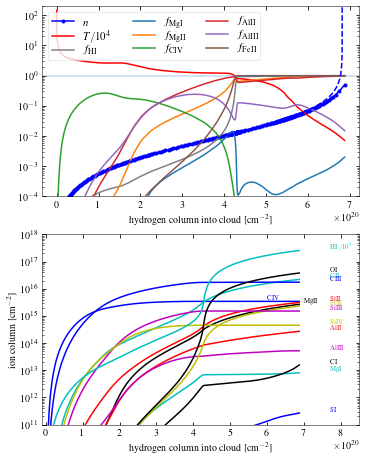

In [37]:
m = LogNormalGrid[k]
xs = m.localColumnDensity()
pl.figure(figsize=(5,7)); pl.subplots_adjust(hspace=0.2)
ax = pl.subplot(211)
pl.plot(xs,m.nH,'.-',c='b',label=r'$n$')
pl.semilogy()
#pl.xlim(1e18,6e20)
pl.plot(xs,m.Ts/1e4,c='r',label=r'$T/10^4$')
pl.plot(xs, m.nHI/m.nH,c='.5',label=r'$f_{\rm HI}$')
pl.plot(xs,10.**m.elementStates['Mg'][0],label=r'$f_{\rm MgI}$')
pl.plot(xs,10.**m.elementStates['Mg'][1],label=r'$f_{\rm MgII}$')
pl.plot(xs,10.**m.elementStates['C'][3],label=r'$f_{\rm CIV}$')
pl.plot(xs,10.**m.elementStates['Al'][1],label=r'$f_{\rm AlII}$')
pl.plot(xs,10.**m.elementStates['Al'][2],label=r'$f_{\rm AlIII}$')
pl.plot(xs,10.**m.elementStates['Fe'][1],label=r'$f_{\rm FeII}$')

fn_template = dir_name+r'/density_law_Rperp2Rvir%.2f_z%.2f_mach%d_Z%.2f_Rvir%d.npz'
print(k,Rperp2Rvir)
fn = fn_template%(Rperp2Rvir,z,mach,Z2Zsun(Rperp2Rvir),Rvir.value)
f = np.load(fn)
medn = (f['log_n'][1:]+f['log_n'][:-1])/2.
NH = (10.**medn*(10**f['log_r'][1:]-10**f['log_r'][:-1])).cumsum()
pl.plot(NH,10**medn,c='b',ls='--')

pl.legend(loc='upper left',fontsize=11,ncol=3)
pl.axhline(1,lw=0.4)
pl.ylim(1e-4,200)
pl.xlabel(r'hydrogen column into cloud [cm$^{-2}$]')


ax = pl.subplot(212)
cs = 'kcbrmy'
for iIon in range(len(elements)-1):
    ionstr = '%s%s'%(elements[iIon],u.roman[ionLevels[iIon]+1])
    labelsuffix,fact = (('',1.),(' $/10^3$',1000))[elements[iIon]=='H']
    if ionstr=='CIV': loc=6e20
    elif ionstr=='MgII': loc=7e20
    else: loc=7.7e20
    pl.text(loc,m.Nion(ionstr)[-1]/fact*1.2,ionstr+labelsuffix,fontsize=7,color=cs[iIon%6])
    pl.plot(xs, m.Nion(ionstr)/fact,c=cs[iIon%6])
pl.semilogy()
pl.ylim(1e11,1e18)
pl.xlim(-0.1e20,8.5e20)
pl.xlabel(r'hydrogen column into cloud [cm$^{-2}$]')
pl.ylabel(r'ion column [cm$^{-2}$]')
pl.savefig(projectdir+'output/%s/0.2Rvir_structure.png'%model_name,bbox_inches='tight',dpi=600)

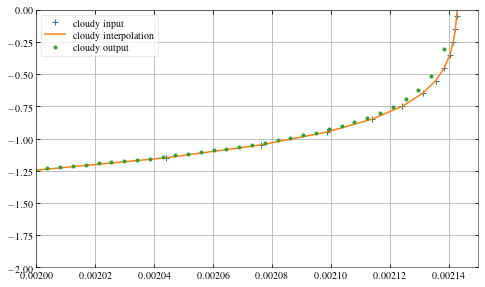

In [38]:
pl.plot(log(depths)-24.42, fixed_log_ns,'+',label='cloudy input')
pl.plot(log(depths)-24.42, fixed_log_ns,label='cloudy interpolation')
pl.plot(log(m.depths)-24.42, log(m.nH),'.',label='cloudy output')
pl.xlim(0.002,0.00215)
pl.ylim(-2,-0.)
pl.legend()
pl.grid()

In [39]:
sorted_keys = sorted(LogNormalGrid.keys(),key=lambda k: (float(strfunc(k[1])[-4:]),-k[0]))

In [41]:
for i,k in enumerate(sorted_keys):
    m = LogNormalGrid[k]
    np.savez('output/%s/cloudy_slab_structure/Rperp%.3f.npz'%(model_name,Rperp2Rvirs[i]),NHs=m.localColumnDensity(), Ts=m.Ts,nHs=m.nH,fHIs=m.nHI/m.nH,
         logf_MgII=m.elementStates['Mg'][1],log_fCIV=m.elementStates['C'][3],log_fAlIII=m.elementStates['Al'][2])


In [42]:
b=100; f_lu=0.4; wl = 2000
NionTau1 = 1e13/0.758 * (f_lu/0.4164)**-1 * (wl/1215.7)**-1 * (b/10.)

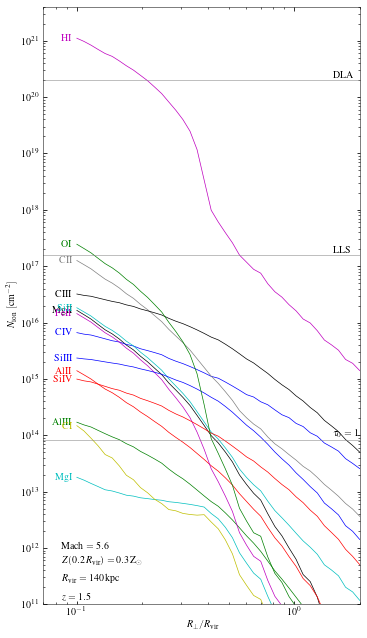

In [43]:
cs = 'k','c','b','r','g','m','y','.5'
dic = {'Rperps':Rperp2Rvirs}
pl.figure(figsize=(5,10))
for iIon in range(0,len(elements)-2):
    #if iIon<6: continue
    ionstr = '%s%s'%(elements[iIon],u.roman[ionLevels[iIon]+1])
    NionsOptThick2 = np.array([LogNormalGrid[k].Nion(ionstr)[-2] for k in sorted_keys])
    NionsOptThick = np.array([LogNormalGrid[k].Nion(ionstr)[-1] for k in sorted_keys])
    dic[ionstr] = NionsOptThick2
    #pl.plot(Rperp2Rvirs_thin,Nions[iIon],c=cs[iIon])
    pl.plot(Rperp2Rvirs,NionsOptThick2,ms=7,c=cs[iIon%8],lw=0.7)
    #pl.plot(Rperps,NionsOptThick,marker='x',ms=7,c=cs[iIon%8],lw=0.3)
    pl.text(0.095,NionsOptThick2[0]/1.1,ionstr,color=cs[iIon%8],ha='right')
pl.loglog()
pl.ylim(1e11,4e21)
pl.xlim(0.07,2)
pl.ylabel(r'$N_{\rm ion}\ [{\rm cm^{-2}}]$')
gca().yaxis.set_major_locator(LogLocator(base=10, subs=(1.0,), numticks=15))
gca().yaxis.set_minor_locator(LogLocator(base=10, subs=range(2,10), numticks=150))
pl.xlabel(r'$R_\perp/R_{\rm vir}$')
pl.text(0.085,1.2e11,r'$z=%.1f$'%z,ha='left')
pl.text(0.085,2.5e11,r'$R_{\rm vir}=%d\,{\rm kpc}$'%Rvir.value,ha='left')
pl.text(0.085,5e11,r'$Z(0.2\,R_{\rm vir})=%.1f\,{\rm Z_\odot}$'%Z2Zsun(0.2),ha='left')
pl.text(0.085,1e12,r'${\rm Mach}=%.1f$'%mach,ha='left')
pl.axhline(10**17.2,lw=0.5,c='.5'); pl.text(1.5,10**17.25,'LLS')
pl.axhline(10**20.3,lw=0.5,c='.5'); pl.text(1.5,10**20.35,'DLA')
pl.axhline(NionTau1,lw=0.5,c='.5'); pl.text(1.5,NionTau1*10**0.05,r'$\tau_0=1$')#+'\n'+r'$(f_{lu}=0.4,b=100,\lambda=2000)$')
#pl.text(0.105,1e13,r'$T=$'%mach,ha='left')
pl.savefig(projectdir+'output/%s/Nions.png'%model_name,bbox_inches='tight',dpi=600)
np.savez('output/%s/Nions_%s.npz'%(model_name,model_name),**dic)

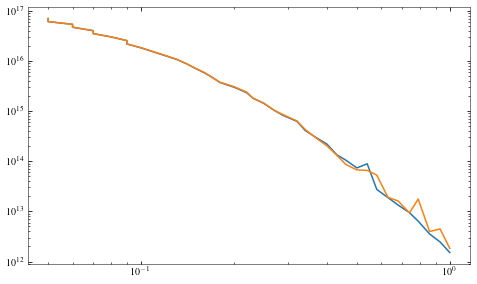

In [59]:
# check effect of turbulence
dic,dic_turb = np.load('Nions.npz'),np.load('Nions_turb.npz')
pl.loglog(dic['Rperps'],dic['MgII'])
pl.loglog(dic_turb['Rperps'],dic_turb['MgII'])

((0.7, 'density_law_files/density_law_Rperp2Rvir0.05_z1.50_mach5_Z0.70_Rvir140'), 0.04885398559319366)


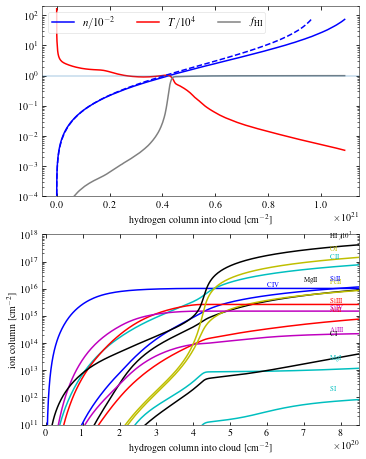

In [107]:
k = [k for k in LogNormalGrid.keys() if LogNormalGrid[k].CloudyOk()][-1]
Rperp2Rvir = Rperp2Rvirs[0]
m = LogNormalGrid[k]
xs = m.Nion('HI')+m.Nion('HII')
pl.figure(figsize=(5,7)); pl.subplots_adjust(hspace=0.2)
ax = pl.subplot(211)
pl.plot(xs,m.nH/1e-2,c='b',label=r'$n/10^{-2}$')
pl.semilogy()
#pl.xlim(1e18,6e20)
pl.plot(xs,m.Ts/1e4,c='r',label=r'$T/10^4$')
pl.plot(xs,10.**m.elementStates['H'][0],c='.5',label=r'$f_{\rm HI}$')
fn_template = r'density_law_files/density_law_Rperp2Rvir%.2f_z%.2f_mach%d_Z%.2f_Rvir%d.npz'

print(k,Rperp2Rvir)
fn = fn_template%(Rperp2Rvir,z,mach,Z2Zsun(Rperp2Rvir),Rvir.value)
f = np.load(fn)
NH = (10.**f['log_n'][:-1]*(10**f['log_r'][1:]-10**f['log_r'][:-1])).cumsum()
pl.plot(NH,10**f['log_n'][:-1]/1e-2,c='b',ls='--')

pl.legend(loc='upper left',fontsize=11,ncol=3)
pl.axhline(1,lw=0.4)
pl.ylim(1e-4,200)
pl.xlabel(r'hydrogen column into cloud [cm$^{-2}$]')


ax = pl.subplot(212)
cs = 'kcbrmy'
for iIon in range(len(elements)-1):
    ionstr = '%s%s'%(elements[iIon],u.roman[ionLevels[iIon]+1])
    labelsuffix,fact = (('',1.),(' $/10^3$',1000))[elements[iIon]=='H']
    if ionstr=='CIV': loc=6e20
    elif ionstr=='MgII': loc=7e20
    else: loc=7.7e20
    pl.text(loc,m.Nion(ionstr)[-1]/fact*1.2,ionstr+labelsuffix,fontsize=7,color=cs[iIon%6])
    pl.plot(xs, m.Nion(ionstr)/fact,c=cs[iIon%6])
pl.semilogy()
pl.ylim(1e11,1e18)
pl.xlim(-0.1e20,8.5e20)
pl.xlabel(r'hydrogen column into cloud [cm$^{-2}$]')
pl.ylabel(r'ion column [cm$^{-2}$]')
pl.savefig(projectdir+'figures/0.05Rvir_structure.png',bbox_inches='tight',dpi=600)

In [41]:
ions = 'MgII','MgII','MgI','CIV','CIV','AlII','AlIII','AlIII','SiII','SI','CI','SiI','FeII','FeII'
wls = 2796,2803,2852,1548,1550,1670,1854,1862,1526,1820,1656,2515,2586,2600
flus = 0.608,0.303,1.8,0.19,0.0962,1.83,0.557,0.277,0.133,0.11,0.2,0.17,None,None
#PI 1774?
b_turb = 100.
tau_0 = lambda N,flu,wl,b: 0.758*N/1e13*flu/0.4164*wl/1215.7*(b/10)**-1    
def EW_approx(wl,flu,b,N,gamma_lu=None): #eqn 9.27 in Draine
    if True: #tau_0<1.25393:
        return np.pi**0.5*b/3e5*tau_0(N,flu,wl,b)/(1+tau_0(N,flu,wl,b)/(2**1.5))*wl
    else:
        return ((2*b/3e5)**2 * ln(tau_0/ln(2))+b/3e5*gamma_lu*wl/3e5*(tau_0-1.25393)/np.pi**0.5)**0.5*wl

('SiII 1526', '0.38 0.64')
('SI 1820', '0.05 0.00')
('CI 1656', '0.05 0.60')
('SiI 2515', '0.05 0.03')


Text(0.5,0,'$R_\\perp/R_{\\rm vir}$')

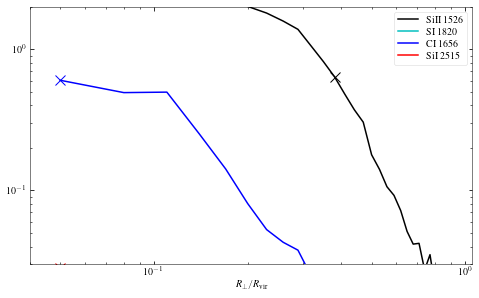

In [42]:
cs = 'k','c','b','r','g','m','y','.5'
Rperps = np.array([float(strfunc(x[1])[-4:]) for x in sorted_keys])
for iIon in range(len(ions)-2):
    if iIon<8: continue
    NionsOptThick = np.array([LogNormalGrid[(float(k[1].split('_')[-2][1:]),k[1])].Nion(ions[iIon])[-1] for k in sorted_keys])
    EWs = EW_approx(wls[iIon],flus[iIon],b_turb,NionsOptThick)
    tau_0s = tau_0(NionsOptThick,flus[iIon],wls[iIon],b_turb)
    ind = (tau_0s<1).nonzero()[0][0]
    pl.plot(Rperps,EWs,ms=7,c=cs[iIon%8],label=ions[iIon]+' '+str(wls[iIon]))
    pl.plot(Rperps[ind:ind+1],EWs[ind:ind+1],'x',ms=10,c=cs[iIon%8])
    print(ions[iIon]+' '+str(wls[iIon]), '%.2f %.2f'%(Rperps[ind:ind+1],EWs[ind:ind+1]))
pl.loglog()
pl.legend(ncol=1,loc='upper right')
pl.ylim(0.03,2)
pl.xlim(0.04,1.05)
#pl.ylabel(r'$N_{\rm ion}\ [{\rm cm^{-2}}]$')
pl.xlabel(r'$R_\perp/R_{\rm vir}$')
#pl.text(0.105,1.2e11,r'$z=%.1f$'%z,ha='left')
#pl.text(0.105,2.5e11,r'$R_{\rm vir}=%d\,{\rm kpc}$'%Rvir.value,ha='left')
#pl.text(0.105,5e11,r'$Z(0.2\,R_{\rm vir})=%.1f\,{\rm Z_\odot}$'%Z2Zsun(0.2),ha='left')
#pl.text(0.105,1e12,r'${\rm Mach}=%.1f$'%mach,ha='left')
#pl.text(0.105,1e13,r'$T=$'%mach,ha='left')
#pl.savefig(projectdir+'figures/Nions.png',bbox_inches='tight',dpi=600)


In [93]:
gamma = 1.5
Tinf = 2e7*un.K
mu = 0.5
csinf = ((cons.k_B*Tinf/(gamma*mu*cons.m_p))**0.5).to('km/s')
MBH = 2e8*un.Msun
RB = (cons.G*MBH/csinf**2).to('pc')
vcRB = ((2*cons.G*MBH/RB)**0.5).to('km/s')
nu = (1e-3*csinf*RB).to('pc*km/s')
tchar = (RB/csinf).to('kyr')

MdotBondi2MdotEdd = 0.01
rhoinf = MdotBondi2MdotEdd/0.1 * 2.3e-21*un.g*un.cm**-3
Lambda = (2./(5.-3*gamma))**((5-3*gamma)/(2*(gamma-1)))/4
MdotBondi = (Lambda*4*np.pi*RB**2*rhoinf*csinf).to('Msun/yr')
MdotEdd = (4*np.pi*cons.G*MBH*cons.m_p/(0.1*cons.sigma_T*cons.c)).to('Msun/yr')
r_e = 2.8179e-15*un.m
j = (0.02**0.5*RB*csinf).to('pc*km/s')
Rc = (j**2/(cons.G*MBH)).to('pc')
vcRcirc = ((2*cons.G*MBH/Rc)**0.5).to('km/s')
ninf = (2.3*0.7*rhoinf/cons.m_p).to('cm**-3') ###
edot_brem_inf = cons.alpha*r_e**2*cons.m_e*cons.c**3*ninf**2*(32/3)*(2/np.pi)**0.5*(cons.k_B*Tinf/(cons.m_e*cons.c**2))**0.5
tcoolinf = (1.5*ninf*cons.k_B*Tinf/edot_brem_inf).to('kyr')
tdyninf = (RB/vcRB).to('kyr')
jdotinf = nu * j/RB**2
theat_viscous_inf = (1.5*cons.k_B*Tinf/cons.m_p/(jdotinf * j/RB**2)).to('kyr')

nRc = ninf * RB/Rc
TRc = Tinf * RB/Rc
edot_brem_Rc = cons.alpha*r_e**2*cons.m_e*cons.c**3*nRc**2*(32/3)*(2/np.pi)**0.5*(cons.k_B*TRc/(cons.m_e*cons.c**2))**0.5
tcoolRc = (1.5*nRc*cons.k_B*TRc/edot_brem_Rc).to('kyr')
tdyn_RC = (Rc/vcRcirc).to('kyr')
jdot_RC = nu * vcRcirc/Rc
tacc_RC = (2./3. * j / jdot_RC).to('kyr') # = Rcirc^2 / nu
theat_viscous_RC = (1.5*cons.k_B*TRc/cons.m_p/(jdot_RC * vcRcirc/Rc)).to('kyr')


print('cs=',csinf)
print('RB=',RB)
print('tchar=',tchar)
print('Rc=',Rc)
print('vcRcirc=',vcRcirc)
print('j=',j)
print('nu=',nu)
print('Lambda=',Lambda)
print('MdotBondi',MdotBondi)
print('MdotEdd',MdotEdd)
print('ninf',ninf)
print('log rhoinf',log(rhoinf.value))
print('Tinf',Tinf)
print('tcoolinf',tcoolinf)
print('theat_viscous_inf',theat_viscous_inf)
print('nRc',nRc)
print('TRc',TRc)
print('tcoolRc',tcoolRc)
print('tchar',tchar)
print('tacc_RC',tacc_RC)
print('theat_viscous_RC',theat_viscous_RC)
print('tdyn',tdyn)
print(MdotBondi/MdotEdd)
print(tchar/tcool)

('cs=', <Quantity 469.1665521968229 km / s>)
('RB=', <Quantity 3.90784202307628 pc>)
('tchar=', <Quantity 8.14435197010457 kyr>)
('Rc=', <Quantity 0.07815684046153 pc>)
('vcRcirc=', <Quantity 4691.66552196823 km / s>)
('j=', <Quantity 259.28598300528284 km pc / s>)
('nu=', <Quantity 1.83342876849655 km pc / s>)
('Lambda=', 0.5)
('MdotBondi', <Quantity 0.15645648764821 solMass / yr>)
('MdotEdd', <Quantity 4.4394597429161 solMass / yr>)
('ninf', <Quantity 221.38894656513693 1 / cm3>)
('log rhoinf', -21.638272163982407)
('Tinf', <Quantity 20000000. K>)
('tcoolinf', <Quantity 89.95917762096246 kyr>)
('theat_viscous_inf', <Quantity 458119.79831838247 kyr>)
('nRc', <Quantity 11069.447328256849 1 / cm3>)
('TRc', <Quantity 1.e+09 K>)
('tcoolRc', <Quantity 12.72214890514953 kyr>)
('tchar', <Quantity 8.14435197010457 kyr>)
('tacc_RC', <Quantity 1.53571373504826 kyr>)
('theat_viscous_RC', <Quantity 1.83247919327353 kyr>)
('tdyn', <Quantity 0.02303570602572 kyr>)
0.035242235927
0.00135800796297


In [35]:
edot_brem.to('erg/s/cm**3')

<Quantity 6.10597756800893e-18 erg / (cm3 s)>

In [43]:
cons.sigma_T.to('cm**2')

<Quantity 6.6524587158e-25 cm2>

In [73]:
np.log10(rhoinf.value)

-20.638272163982407

In [77]:
10**-21.57/10**-23.3

53.70317963702532

In [94]:
50**0.25

2.6591479484724942

In [95]:
1.7/4+1

1.425

In [1]:
3

3

In [5]:
(4.4*un.pc*0.01*un.cm**-3*6e-18*un.cm**2).to('')

<Quantity 0.81461888>